# Grinsztajn Tabular Benchmark: Standardized Datasets for Balance-Guided Oblique Trees

This notebook demonstrates the **Grinsztajn Tabular Benchmark** dataset — 5 standardized tabular benchmark datasets (electricity, adult, california_housing, jannis, higgs_small) from Grinsztajn et al. 2022 / HuggingFace / sklearn.

**What this artifact does:**
- Loads per-dataset JSONL files from a manifest and converts them into a grouped JSON schema
- Each example has JSON-stringified feature inputs, string outputs, 5-fold CV assignments (stratified), and full provenance metadata
- Total: 247,305 examples across 4 binary classification + 1 regression task, spanning 6–54 numeric features

This demo loads a mini subset and walks through the data processing pipeline.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import sys
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

# Configure logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/dataset_iter1_grinsztajn_tabu/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
logger.info(f"Loaded {len(data['datasets'])} datasets")
for ds in data["datasets"]:
    logger.info(f"  {ds['dataset']}: {len(ds['examples'])} examples")

11:04:23|INFO   |Loaded 5 datasets


11:04:23|INFO   |  electricity: 3 examples


11:04:23|INFO   |  adult: 3 examples


11:04:23|INFO   |  california_housing: 3 examples


11:04:23|INFO   |  jannis: 3 examples


11:04:23|INFO   |  higgs_small: 3 examples


In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
# Tunable parameters — start with absolute minimums
MAX_EXAMPLES_PER_DATASET = 3   # number of examples to process per dataset (min=1)
MAX_FILE_SIZE_BYTES = 100 * 1024 * 1024  # 100 MB limit per output part (from original script)

## Processing: Parse and Convert Dataset Records

The original script reads JSONL files from a manifest and converts each record to the grouped schema format. Here we replicate that conversion logic on the loaded mini data: parsing JSON-stringified inputs, mapping task types, and assembling the grouped output structure.

In [6]:
def task_type_label(task: str) -> str:
    """Map detailed task names to simple classification/regression."""
    if "classification" in task:
        return "classification"
    return "regression"


# Process each dataset — mirrors the original data.py conversion logic
all_datasets = []

for ds in data["datasets"]:
    name = ds["dataset"]
    examples_raw = ds["examples"][:MAX_EXAMPLES_PER_DATASET]

    logger.info(f"Processing {name}: {len(examples_raw)} examples")

    # Convert each record to schema format
    examples = []
    for row_idx, rec in enumerate(examples_raw):
        # input: already a JSON string — parse to verify, then re-serialize compactly
        input_dict = json.loads(rec["input"])
        input_str = json.dumps(input_dict, separators=(",", ":"))

        # output: convert to string
        output_str = str(rec["output"])

        example = {
            "input": input_str,
            "output": output_str,
            "metadata_fold": rec["metadata_fold"],
            "metadata_feature_names": rec["metadata_feature_names"],
            "metadata_task_type": task_type_label(rec["metadata_task_type"]),
            "metadata_source": rec["metadata_source"],
            "metadata_row_index": row_idx,
        }

        # Add n_classes only for classification
        if "metadata_n_classes" in rec:
            example["metadata_n_classes"] = rec["metadata_n_classes"]

        examples.append(example)

    logger.info(f"  Converted {len(examples)} examples for {name}")

    all_datasets.append({
        "dataset": name,
        "examples": examples,
    })

    # Free memory
    del examples_raw
    gc.collect()

logger.info(f"Total: {len(all_datasets)} datasets, "
            f"{sum(len(d['examples']) for d in all_datasets)} examples")

11:04:23|INFO   |Processing electricity: 3 examples


11:04:23|INFO   |  Converted 3 examples for electricity


11:04:23|INFO   |Processing adult: 3 examples


11:04:23|INFO   |  Converted 3 examples for adult


11:04:23|INFO   |Processing california_housing: 3 examples


...

11:04:23|INFO   |Processing jannis: 3 examples


11:04:23|INFO   |  Converted 3 examples for jannis


11:04:23|INFO   |Processing higgs_small: 3 examples


11:04:23|INFO   |  Converted 3 examples for higgs_small


11:04:23|INFO   |Total: 5 datasets, 15 examples


## Output Partitioning

The original script splits large outputs into parts that each stay under 100 MB. Here we replicate that size-estimation and grouping logic on our mini data.

In [7]:
def estimate_size(ds_dict: dict) -> int:
    """Rough byte estimate of a dataset dict serialized as compact JSON."""
    return len(json.dumps(ds_dict, separators=(",", ":")))

# Group datasets into parts under the size limit
parts: list[dict] = []
current_datasets: list[dict] = []
current_size_est = 50  # overhead for {"datasets":[...]}

for ds in all_datasets:
    ds_size = estimate_size(ds)
    if current_size_est + ds_size < MAX_FILE_SIZE_BYTES:
        current_datasets.append(ds)
        current_size_est += ds_size
    else:
        # Flush current batch if non-empty
        if current_datasets:
            parts.append({"datasets": current_datasets})
            current_datasets = []
            current_size_est = 50

        # Check if single dataset exceeds limit
        if ds_size < MAX_FILE_SIZE_BYTES:
            current_datasets.append(ds)
            current_size_est += ds_size
        else:
            # Split large dataset's examples into chunks
            examples = ds["examples"]
            chunk_size = len(examples) // ((ds_size // MAX_FILE_SIZE_BYTES) + 1)
            for start in range(0, len(examples), chunk_size):
                chunk_ds = {"dataset": ds["dataset"],
                            "examples": examples[start:start + chunk_size]}
                parts.append({"datasets": [chunk_ds]})
                logger.info(f"  Split {ds['dataset']} chunk: "
                            f"examples {start}-{min(start+chunk_size, len(examples))}")

if current_datasets:
    parts.append({"datasets": current_datasets})

# Report partitioning results
total_examples = sum(len(ds["examples"]) for ds in all_datasets)
logger.info(f"Partitioned into {len(parts)} parts")
for i, part in enumerate(parts, 1):
    n_ex = sum(len(d["examples"]) for d in part["datasets"])
    size_est = estimate_size(part)
    ds_names = [d["dataset"] for d in part["datasets"]]
    logger.info(f"  Part {i}: ~{size_est/1e3:.1f} KB, {n_ex} examples, datasets={ds_names}")

11:04:23|INFO   |Partitioned into 1 parts


11:04:23|INFO   |  Part 1: ~12.3 KB, 15 examples, datasets=['electricity', 'adult', 'california_housing', 'jannis', 'higgs_small']


## Summary Statistics

Print a summary table of all datasets: name, number of examples, task type, number of features, and data source.

In [8]:
# Build summary table
summary_rows = []
for ds in all_datasets:
    ex = ds["examples"][0]
    n_features = len(json.loads(ex["input"]))
    summary_rows.append({
        "Dataset": ds["dataset"],
        "Examples": len(ds["examples"]),
        "Task Type": ex["metadata_task_type"],
        "Features": n_features,
        "Source": ex["metadata_source"],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f"\nTotal examples: {sum(r['Examples'] for r in summary_rows)}")
print(f"Total datasets: {len(summary_rows)}")

           Dataset  Examples      Task Type  Features                                              Source
       electricity         3 classification         7 hf_inria-soda/tabular-benchmark_clf_num_electricity
             adult         3 classification         6                 hf_scikit-learn/adult-census-income
california_housing         3     regression         8                          sklearn_california_housing
            jannis         3 classification        54      hf_inria-soda/tabular-benchmark_clf_num_jannis
       higgs_small         3 classification        24       hf_inria-soda/tabular-benchmark_clf_num_Higgs

Total examples: 15
Total datasets: 5


## Visualization

Plot the number of features per dataset and show the feature value distributions for one example dataset (electricity).

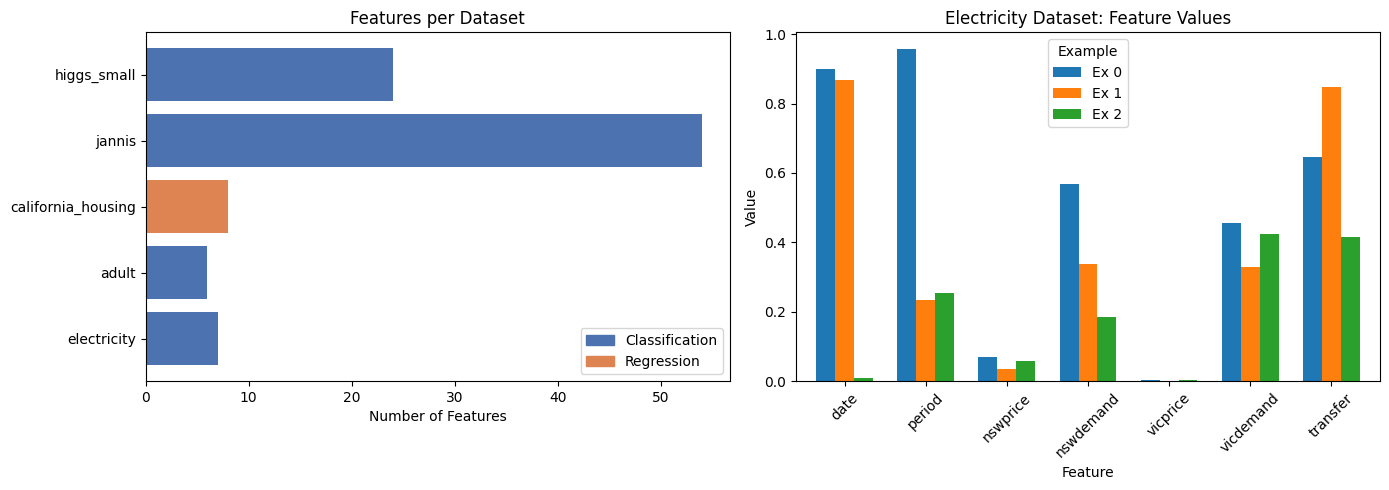

Saved: dataset_overview.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: Number of features per dataset ──
ds_names = [r["Dataset"] for r in summary_rows]
n_feats = [r["Features"] for r in summary_rows]
colors = ["#4C72B0" if r["Task Type"] == "classification" else "#DD8452" for r in summary_rows]

axes[0].barh(ds_names, n_feats, color=colors)
axes[0].set_xlabel("Number of Features")
axes[0].set_title("Features per Dataset")
# Legend for task type
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color="#4C72B0", label="Classification"),
                        Patch(color="#DD8452", label="Regression")],
               loc="lower right")

# ── Right panel: Feature values for electricity dataset ──
elec_ds = next(ds for ds in all_datasets if ds["dataset"] == "electricity")
elec_features = []
for ex in elec_ds["examples"]:
    feats = json.loads(ex["input"])
    elec_features.append(feats)
elec_df = pd.DataFrame(elec_features)

elec_df.T.plot(kind="bar", ax=axes[1], legend=True, width=0.7)
axes[1].set_title("Electricity Dataset: Feature Values")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Value")
axes[1].legend(title="Example", labels=[f"Ex {i}" for i in range(len(elec_df))])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: dataset_overview.png")